In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

In [2]:
# Define your metrics
metrics = ['Spearman Correlation', 'L1 Error', 'RMSE']

# Define a custom palette for Likelihood values
custom_palette = {
    "Binomial": sns.color_palette("deep")[2],  # Third color in the 'deep' palette
    "Beta-Binomial": sns.color_palette("deep")[4]  # Fourth color in the 'deep' palette
}

In [22]:
# Define the paths
all_models = "/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/ATSEs"

# Get the list of CSV files in each directory
all_TS_files = glob.glob(os.path.join(all_models, '*/final_results.csv'))

# Create a function to read and concatenate CSV files from a list of file paths
def concatenate_files(file_list, label):
    dfs = []
    for file in file_list:
        print(file)
        # Ensure that the file is not empty
        if os.path.getsize(file) == 0:
            continue
        df = pd.read_csv(file)
        df['Source'] = label  # Add a label for each set (e.g., 'All Tissues CPU', 'Brain CPU', etc.)
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

# Combine all DataFrames into one
all_TS_files_df = concatenate_files(all_TS_files, 'All_Tabula_Sapien')

/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/ATSEs/analysis_20250109_170200_K_50_UsingWaypoints_Prior_GlobalPrior_NumEpochs_500_ConcPrior_inf_Inits_3_CellType_cell_type_grouped_Random_67406/final_results.csv
/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/ATSEs/analysis_20250109_165321_K_30_UsingWaypoints_Prior_GlobalPrior_NumEpochs_500_LearnedConc_Inits_3_CellType_cell_type_grouped_Random_80518/final_results.csv
/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/ATSEs/analysis_20250109_170200_K_50_UsingWaypoints_Prior_GlobalPrior_NumEpochs_500_LearnedConc_Inits_3_CellType_cell_type_grouped_Random_67540/final_results.csv
/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/ATSEs/analysis_20250109_165757_K_50_UsingWaypoints_Prior_NoGlobalPrior_NumEpochs_500_ConcPrior_inf_Inits_3_CellType_cell_type_grouped_Random_14285/final_results.csv
/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/ATSEs/analysis_20250109_165321_K_30_UsingWaypoints_Prior_GlobalPrior_NumEpochs_5

#### Full analysis without masking!

In [24]:
all_TS_files_df["ELBO_log10"] = np.log10(all_TS_files_df["best_elbo"])
all_TS_files_df["Likelihood"] = all_TS_files_df["learned_conc"].apply(lambda x: "Binomial" if x == float('inf') else "Beta-Binomial")
all_TS_files_df["junc_prior"] = all_TS_files_df["use_global_prior"].apply(lambda x: "J_prior" if x else "noJ_prior")
all_TS_files_df['combined_prior_input'] = all_TS_files_df['junc_prior'].astype(str) + '-' + all_TS_files_df['Likelihood']
all_TS_files_df['unique_model_att'] = all_TS_files_df['combined_prior_input'].astype(str) + '-' + all_TS_files_df['wayp'] + '-' + all_TS_files_df['K'].astype(str) 
all_TS_files_df["K_diff"] = all_TS_files_df["K"] - all_TS_files_df["new_K"]
all_TS_files_df = all_TS_files_df[all_TS_files_df["K"] <=100]
all_TS_files_df["Waypoint Initialized"] = all_TS_files_df["wayp"]
all_TS_files_df["best_elbo_trans"] = all_TS_files_df["best_elbo"] / 1e6

In [28]:
all_TS_files_df.sort_values("best_elbo_trans")

,K,new_K,use_global_prior,learning_rate,avg_corr,median_corr,min_corr,silhouette_avg,dbi,cell_type_column,...,overall_cell_total_entropy,Source,ELBO_log10,Likelihood,junc_prior,combined_prior_input,unique_model_att,K_diff,Waypoint Initialized,best_elbo_trans
1,30,30,True,0.1,0.955326,0.955187,0.954999,-0.170576,10.015450,cell_type_grouped,...,59176.258073,All_Tabula_Sapien,7.528482,Beta-Binomial,J_prior,J_prior-Beta-Binomial,J_prior-Beta-Binomial-YES-30,0,YES,33.766199
6,30,30,False,0.1,0.962266,0.962076,0.962001,-0.163032,9.860426,cell_type_grouped,...,56570.118362,All_Tabula_Sapien,7.529871,Beta-Binomial,noJ_prior,noJ_prior-Beta-Binomial,noJ_prior-Beta-Binomial-YES-30,0,YES,33.874358
2,50,50,True,0.1,0.931433,0.931565,0.930246,-0.188205,9.561916,cell_type_grouped,...,71567.396911,All_Tabula_Sapien,7.531116,Beta-Binomial,J_prior,J_prior-Beta-Binomial,J_prior-Beta-Binomial-YES-50,0,YES,33.971601
7,50,50,False,0.1,0.955815,0.954618,0.951462,-0.177861,9.686950,cell_type_grouped,...,64833.848804,All_Tabula_Sapien,7.532897,Beta-Binomial,noJ_prior,noJ_prior-Beta-Binomial,noJ_prior-Beta-Binomial-YES-50,0,YES,34.111208
0,50,50,True,0.1,0.960496,0.959979,0.959377,-0.123036,13.663641,cell_type_grouped,...,43151.355358,All_Tabula_Sapien,8.472791,Binomial,J_prior,J_prior-Binomial,J_prior-Binomial-YES-50,0,YES,297.023927
3,50,50,False,0.1,0.960462,0.958874,0.958449,-0.122607,13.642172,cell_type_grouped,...,43197.798711,All_Tabula_Sapien,8.473106,Binomial,noJ_prior,noJ_prior-Binomial,noJ_prior-Binomial-YES-50,0,YES,297.239210
5,30,30,False,0.1,0.963874,0.963936,0.962691,-0.118912,13.203882,cell_type_grouped,...,40559.988687,All_Tabula_Sapien,8.499017,Binomial,noJ_prior,noJ_prior-Binomial,noJ_prior-Binomial-YES-30,0,YES,315.512493
4,30,30,True,0.1,0.962531,0.962003,0.960933,-0.121699,13.200528,cell_type_grouped,...,40504.507939,All_Tabula_Sapien,8.499154,Binomial,J_prior,J_prior-Binomial,J_prior-Binomial-YES-30,0,YES,315.612088


In [6]:
def get_best_model(data, dbi_column='dbi', silhouette_column='silhouette_avg', min_corr_column='min_corr',
                   prior_input_column='combined_prior_input', wayp_column='wayp', old_k_column='K', new_k_column='new_K',
                   cell_type_accuracy_column='cell_type_accuracy'):
    """
    Function to find and print the model with the lowest DBI, highest silhouette_avg, lowest min_corr, and reports cell_type_accuracy.
    Returns details about the best models including combined_prior_input, waypoint status, old K, new K, and cell_type_accuracy.

    Parameters:
    - data: DataFrame containing the models and their performance metrics.
    - dbi_column: The column name for DBI (default is 'dbi').
    - silhouette_column: The column name for silhouette score (default is 'silhouette_avg').
    - min_corr_column: The column name for minimum correlation (default is 'min_corr').
    - prior_input_column: The column name for combined prior input (default is 'combined_prior_input').
    - wayp_column: The column name for waypoint status (default is 'wayp').
    - old_k_column: The column name for old K (default is 'K').
    - new_k_column: The column name for new K (default is 'new_K').
    - cell_type_accuracy_column: The column name for cell type accuracy (default is 'cell_type_accuracy').

    Returns:
    - A dictionary with details of the best models for each criterion.
    """

    # Get the model with the lowest DBI
    best_dbi_model = data.loc[data[dbi_column].idxmin()]
    # Get the model with the highest silhouette_avg
    best_silhouette_model = data.loc[data[silhouette_column].idxmax()]
    # Get the model with the lowest min_corr
    best_min_corr_model = data.loc[data[min_corr_column].idxmax()]

    # Extract and print relevant details for each best model, including cell type accuracy
    best_dbi_info = {
        'combined_prior_input': best_dbi_model[prior_input_column],
        'wayp': best_dbi_model[wayp_column],
        'old_K': best_dbi_model[old_k_column],
        'new_K': best_dbi_model[new_k_column],
        'DBI': best_dbi_model[dbi_column],
        'Cell Type Accuracy': best_dbi_model[cell_type_accuracy_column]
    }

    best_silhouette_info = {
        'combined_prior_input': best_silhouette_model[prior_input_column],
        'wayp': best_silhouette_model[wayp_column],
        'old_K': best_silhouette_model[old_k_column],
        'new_K': best_silhouette_model[new_k_column],
        'Silhouette Score': best_silhouette_model[silhouette_column],
        'Cell Type Accuracy': best_silhouette_model[cell_type_accuracy_column]
    }

    best_min_corr_info = {
        'combined_prior_input': best_min_corr_model[prior_input_column],
        'wayp': best_min_corr_model[wayp_column],
        'old_K': best_min_corr_model[old_k_column],
        'new_K': best_min_corr_model[new_k_column],
        'Min Correlation': best_min_corr_model[min_corr_column],
        'Cell Type Accuracy': best_min_corr_model[cell_type_accuracy_column]
    }

    # Print the results
    print(f"Best model by lowest DBI: \n{best_dbi_info}\n")
    print(f"Best model by highest Silhouette score: \n{best_silhouette_info}\n")
    print(f"Best model by lowest Min Correlation: \n{best_min_corr_info}\n")

    # Return the best model details as a dictionary
    return {
        'best_dbi_model': best_dbi_info,
        'best_silhouette_model': best_silhouette_info,
        'best_min_corr_model': best_min_corr_info
    }

In [7]:
def plot_facet_scatter(data, x_column, y_column, hue_column='wayp', order_column='combined_prior_input', save_fig=False, line_position=None, connect_dots=False):
    """
    Generalized function to create a scatter plot with facets based on order_column and color by waypoint status.
    
    Parameters:
    - data: DataFrame containing the results
    - x_column: The column name to plot on the x-axis (e.g., 'new_K')
    - y_column: The column name to plot on the y-axis (column of interest)
    - hue_column: The column used to color the points (default is 'wayp')
    - order_column: The column used to facet the plots (default is 'combined_prior_input')
    - save_fig: Whether to save the figure in the 'date_figures' folder (default is False)
    - line_position: 'lowest' or 'highest', adds a red dotted line at either the lowest or highest point on the y-axis.
    - connect_dots: Whether to connect the dots for each hue group (default is False)
    """

    # Define the desired order for the combined_prior_input column
    desired_order = ['J_prior-binomial', 'noJ_prior-binomial', 'J_prior-beta-binomial', 'noJ_prior-beta-binomial']

    # Set the plot theme to a grey grid
    sns.set_style("darkgrid")

    # Create a FacetGrid with the specified order and set it to display two columns
    g = sns.FacetGrid(data, col=order_column, hue=hue_column, col_wrap=2, height=4, sharey=True, col_order=desired_order)

    if connect_dots:
        # Use lineplot to connect dots and add scatterplot on top for visibility of points
        g.map(sns.lineplot, x_column, y_column, marker="o")  # Connect dots with lines
    else:
        # Standard scatterplot without line connection
        g.map(sns.scatterplot, x_column, y_column)

    # Add the red dotted line at either the lowest or highest point, if specified
    if line_position in ['lowest', 'highest']:
        for ax in g.axes.flat:
            if line_position == 'lowest':
                y_val = data[y_column].min()  # Get the minimum value of y_column
            elif line_position == 'highest':
                y_val = data[y_column].max()  # Get the maximum value of y_column
            
            # Add a horizontal red dotted line at the specified y-axis point
            ax.axhline(y=y_val, color='red', linestyle='--')

    # Add legend and adjust layout
    g.add_legend()
    g.set_axis_labels(x_column, y_column)
    g.set_titles(col_template="{col_name}")

    # Adjust layout
    plt.tight_layout()

    # If save_fig is True, save the plot to 'date_figures' folder
    if save_fig:
        # Create the folder if it doesn't exist
        if not os.path.exists('date_figures'):
            os.makedirs('date_figures')

        # Get the current date
        current_date = datetime.now().strftime('%Y-%m-%d')

        # Define the file name with the date and column names
        file_name = f"date_figures/{current_date}_facet_scatter_{x_column}_vs_{y_column}_by_{order_column}.png"

        # Save the figure
        plt.savefig(file_name, bbox_inches='tight')
        print(f"Figure saved as {file_name}")

    # Show the plot
    plt.show()

In [8]:
def plot_column_vs_elbo(data, column_name, y_column='ELBO_log10', hue_column='K', order_column='combined_prior_input', 
                        save_fig=False, leg_loc_left="lower right", leg_loc_right="upper left", show_min_line=True, specific_K=None):
    """
    Generalized function to plot barplots of ELBO_log10 vs. a given column and optionally display a horizontal red line at the minimum y_column value.
    
    Parameters:
    - data: DataFrame containing the results
    - column_name: The column name to plot on the x-axis (e.g., 'combined_prior_input')
    - y_column: The column name to plot on the y-axis (default is 'ELBO_log10')
    - hue_column: The column name used for the hue (default is 'K')
    - order_column: The column to order the x-axis values (default is 'combined_prior_input')
    - save_fig: Whether to save the figure in the 'date_figures' folder (default is False)
    - leg_loc_left: Legend location for the left subplot (default is "lower right")
    - leg_loc_right: Legend location for the right subplot (default is "upper left")
    - show_min_line: Whether to draw a horizontal dashed red line at the minimum y_column value (default is True)
    - specific_K: Optional. If provided, only plots the data for the specified value of K.
    """

    # Set the plot theme to a grey grid
    sns.set_style("darkgrid")

    # Filter the data for the specific K if provided
    if specific_K is not None:
        data = data[data[hue_column] == specific_K]

    # Define the order of the column based on the unique values from the data (sorted or in a specific order you want)
    # column_order = sorted(data[order_column].unique())
    column_order = ['J_prior-binomial', 'noJ_prior-binomial', 'J_prior-beta-binomial', 'noJ_prior-beta-binomial']

    # Get the minimum value of the y_column
    min_y_value = data[y_column].min()

    # Create a figure with two subplots (side-by-side)
    fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharey=True)  # Share y-axis for comparison

    # First plot (waypoints == "NO")
    sns.barplot(x=column_name, y=y_column, hue=hue_column, data=data[data["wayp"] == "NO"],
                ax=axes[0], order=column_order)
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
    axes[0].set_xlabel(f"{column_name}")
    axes[0].legend(loc=leg_loc_left)
    axes[0].set_title('Waypoints: NO')

    # Add horizontal dashed red line at minimum y_column value
    if show_min_line:
        axes[0].axhline(min_y_value, color='red', linestyle='--', label=f'Min {y_column}')
    
    # Second plot (waypoints == "YES") with the same y-limits and same order
    sns.barplot(x=column_name, y=y_column, hue=hue_column, data=data[data["wayp"] == "YES"],
                ax=axes[1], order=column_order)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)
    axes[1].set_xlabel(f"{column_name}")
    axes[1].legend(loc=leg_loc_right)
    axes[1].set_title('Waypoints: YES')

    # Add horizontal dashed red line at minimum y_column value
    if show_min_line:
        axes[1].axhline(min_y_value, color='red', linestyle='--', label=f'Min {y_column}')

    # Adjust layout
    plt.tight_layout()

    # If save_fig is True, save the plot to 'date_figures' folder
    if save_fig:
        # Create the folder if it doesn't exist
        if not os.path.exists('date_figures'):
            os.makedirs('date_figures')

        # Get the current date
        current_date = datetime.now().strftime('%Y-%m-%d')

        # Define the file name with the date and column name
        if specific_K is not None:
            file_name = f"date_figures/{current_date}_{column_name}_vs_{y_column}_K_{specific_K}.png"
        else:
            file_name = f"date_figures/{current_date}_{column_name}_vs_{y_column}.png"

        # Save the figure
        plt.savefig(file_name, bbox_inches='tight')
        print(f"Figure saved as {file_name}")

    # Show the plot
    plt.show()

In [9]:
def plot_results_panels_waypoints(data, add_suff="all_tissues", save_fig=False):
    """
    Creates a 2x2 panel of line plots comparing performance metrics across different conditions.
    
    Parameters:
    - data: DataFrame containing the relevant columns for plotting
    - save_fig: bool, optional, if True the figure will be saved as a PNG file
    """
    # Define the performance metrics to be plotted in each panel
    panel_a_metric = 'new_K'
    panel_b_metric = 'ELBO_log10'
    panel_c_metric = 'median_corr'
    panel_d_metric = 'cell_type_accuracy'

    # Set the plot theme
    sns.set_theme(style="white", palette=None)

    # Convert 'K' to ordered categorical for proper axis handling
    K_order = ['20', '30', '50', '100', '200']  # String representation of the categories
    data['K_ord'] = pd.Categorical(data['K'].astype(str), categories=K_order, ordered=True)

    # Create subplots
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    # Panel A: Number of Factors Inferred (Pruned K) with waypoint vs no waypoint comparison
    sns.lineplot(data=data, x='K_ord', y=panel_a_metric, hue='Likelihood', style="wayp", err_style="bars", markers=True, dashes=True, errorbar=("se", 2), ax=axs[0, 0], palette=custom_palette)
    axs[0, 0].set_ylabel('Pruned K')
    axs[0, 0].set_xlabel('Input K')
    axs[0, 0].legend(fontsize='xx-small')  # Reduce legend font size for Panel A

    # Panel B: ELBO (Evidence Lower Bound) Values comparing waypoint vs no waypoint
    sns.lineplot(data=data, x='K_ord', y=panel_b_metric, hue='Likelihood', style="wayp", err_style="bars", markers=True, dashes=True, errorbar=("se", 2), ax=axs[0, 1], palette=custom_palette)
    axs[0, 1].set_ylabel('ELBO (log10)')
    axs[0, 1].legend(fontsize='xx-small')  # Reduce legend font size for Panel B

    # Panel C: Correlations Between Latent Variables (median_corr)
    sns.lineplot(data=data, x='K_ord', y=panel_c_metric, hue='Likelihood', style="wayp", err_style="bars", markers=True, dashes=True, errorbar=("se", 2), ax=axs[1, 0], palette=custom_palette)
    axs[1, 0].set_ylabel('Correlation among initializations')
    axs[1, 0].legend(fontsize='xx-small')  # Reduce legend font size for Panel C

    # Panel D: Cell type accuracy with y-axis limit between 0.5 and 1
    sns.lineplot(data=data, x='K_ord', y=panel_d_metric, hue='Likelihood', style="wayp", err_style="bars", markers=True, dashes=True, errorbar=("se", 2), ax=axs[1, 1], palette=custom_palette)
    axs[1, 1].set_ylabel('Cell type accuracy')
    axs[1, 1].legend(fontsize='xx-small')  # Reduce legend font size for Panel D

    # Adjust layout
    plt.tight_layout()

    # Save figure if required
    if save_fig:
        # Create the folder if it doesn't exist
        if not os.path.exists('date_figures'):
            os.makedirs('date_figures')

        current_date = datetime.now().strftime('%Y-%m-%d')
        file_name = f"date_figures/{current_date}_{add_suff}_leaflet_fa_results_panels_waypoints.png"
        plt.savefig(file_name, bbox_inches='tight')
        print(f"Figure saved as {file_name}")

    # Show the plot
    plt.show()


In [10]:
def plot_results_junc_prior_boxplots(data, add_suff="all_tissues", save_fig=False):
    """
    Creates a 2x2 panel of boxplots comparing performance metrics across different conditions.
    
    Parameters:
    - data: DataFrame containing the relevant columns for plotting
    - save_fig: bool, optional, if True the figure will be saved as a PNG file
    """
    # Set the plot theme
    sns.set_theme(style="white", palette=None)

    # Create subplots (2 rows, 2 columns)
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    # Panel A: Boxplot for mean_cell_entropy vs junc_prior, grouped by new_K
    sns.boxplot(data=data, x="junc_prior", y="mean_cell_entropy", hue="new_K", ax=axs[0, 0])
    axs[0, 0].set_title('Mean Cell Entropy')
    axs[0, 0].legend(fontsize='xx-small')

    # Panel B: Boxplot for ELBO_log10 vs junc_prior, grouped by new_K
    sns.boxplot(data=data, x="junc_prior", y="ELBO_log10", hue="new_K", ax=axs[0, 1])
    axs[0, 1].set_title('ELBO (log10)')
    axs[0, 1].legend(fontsize='xx-small')

    # Panel C: Boxplot for median_corr vs junc_prior, grouped by wayp
    sns.boxplot(data=data, x="junc_prior", y="median_corr", hue="wayp", ax=axs[1, 0])
    axs[1, 0].set_title('Median Correlation')
    axs[1, 0].legend(fontsize='xx-small')

    # Panel D: Boxplot for dbi vs junc_prior, grouped by new_K
    sns.boxplot(data=data, x="junc_prior", y="dbi", hue="new_K", ax=axs[1, 1])
    axs[1, 1].set_title('DBI (Davies-Bouldin Index)')
    axs[1, 1].legend(fontsize='xx-small')

    # Adjust layout for better spacing
    plt.tight_layout()

    # Save figure if required
    if save_fig:
        # Create the folder if it doesn't exist
        if not os.path.exists('date_figures'):
            os.makedirs('date_figures')

        # Get current date
        current_date = datetime.now().strftime('%Y-%m-%d')
        file_name = f"date_figures/{current_date}_{add_suff}_leaflet_boxplots_results.png"
        
        # Save the figure
        plt.savefig(file_name, bbox_inches='tight')
        print(f"Figure saved as {file_name}")

    # Show the plot
    plt.show()


In [11]:
def plot_results_panels_waypoints(data, add_suff="all_tissues", save_fig=False):
    """
    Creates a panel of line plots comparing performance metrics across different conditions.
    
    Parameters:
    - data: DataFrame containing the relevant columns for plotting
    - save_fig: bool, optional, if True the figure will be saved as a PNG file
    """
    # Define the performance metrics to be plotted in each panel
    panel_a_metric = 'new_K'
    panel_b_metric = 'median_corr'
    panel_c_metric = 'cell_type_accuracy'

    # Set the plot theme
    sns.set_theme(style="white", palette=None)

    # Convert 'K' to ordered categorical for proper axis handling
    K_order = ['20', '30', '50', '100']  # String representation of the categories
    data['K_ord'] = pd.Categorical(data['K'].astype(str), categories=K_order, ordered=True)

    # Create subplots (3 plots in a row)
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # Adjusting for less wide plots

    # Panel A: Number of Factors Inferred (Pruned K) with waypoint vs no waypoint comparison
    sns.lineplot(
        data=data, x='K_ord', y=panel_a_metric, hue='Likelihood', style="Waypoint Initialized", 
        err_style="bars", markers=True, dashes=True, errorbar=("se", 2), ax=axs[0], palette=custom_palette
    )
    axs[0].set_ylabel('Pruned K', fontsize=16)
    axs[0].set_xlabel('Input K', fontsize=16)
    axs[0].tick_params(axis='x', labelsize=14)
    axs[0].tick_params(axis='y', labelsize=14)

    # Panel B: Correlations Between Latent Variables (median_corr)
    sns.lineplot(
        data=data, x='K_ord', y=panel_b_metric, hue='Likelihood', style="Waypoint Initialized", 
        err_style="bars", markers=True, dashes=True, errorbar=("se", 2), ax=axs[1], palette=custom_palette
    )
    axs[1].set_ylabel('Correlation among \ninitializations', fontsize=16)
    axs[1].set_xlabel('Input K', fontsize=16)
    axs[1].tick_params(axis='x', labelsize=14)
    axs[1].tick_params(axis='y', labelsize=14)

    # Panel C: Cell type accuracy
    sns.lineplot(
        data=data, x='K_ord', y=panel_c_metric, hue='Likelihood', style="Waypoint Initialized", 
        err_style="bars", markers=True, dashes=True, errorbar=("se", 2), ax=axs[2], palette=custom_palette
    )
    axs[2].set_ylabel('Cell type accuracy', fontsize=16)
    axs[2].set_xlabel('Input K', fontsize=16)
    axs[2].tick_params(axis='x', labelsize=14)
    axs[2].tick_params(axis='y', labelsize=14)

    # Remove legends from individual subplots
    for ax in axs.flatten():
        ax.legend_.remove()

    # Adjust layout
    plt.tight_layout()

    # Save figure if required
    if save_fig:
        # Create the folder if it doesn't exist
        if not os.path.exists('date_figures'):
            os.makedirs('date_figures')

        current_date = datetime.now().strftime('%Y-%m-%d')
        file_name = f"date_figures/{current_date}_{add_suff}_leaflet_fa_results_panels_waypoints.png"
        plt.savefig(file_name, bbox_inches='tight')
        print(f"Figure saved as {file_name}")

    # Show the plot
    plt.show()


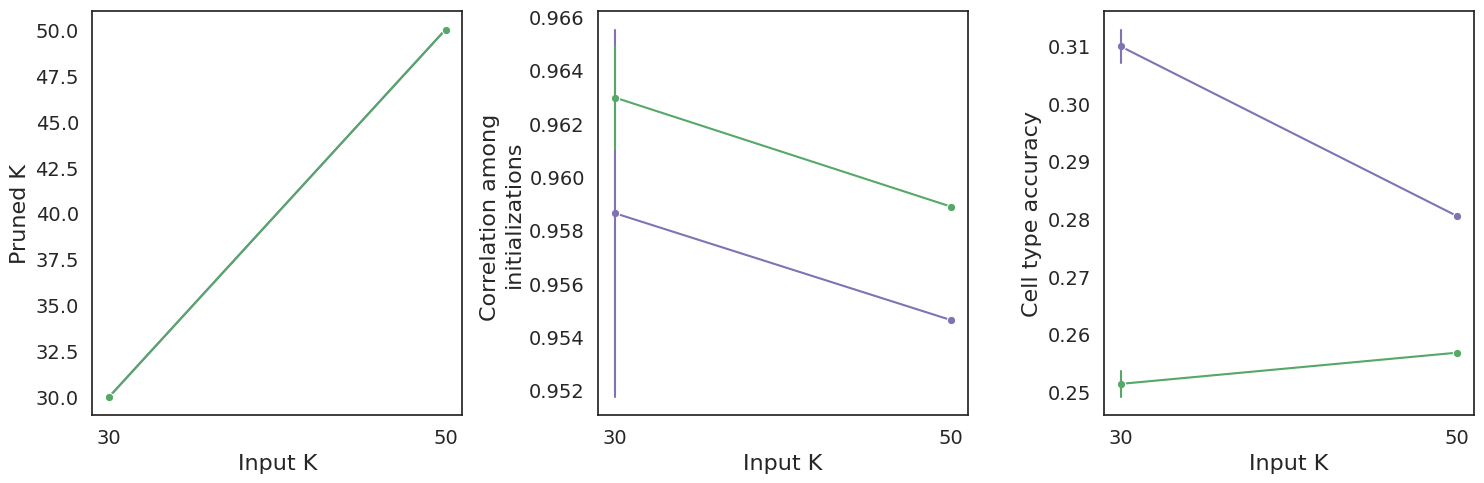

In [12]:
all_TS_files_df.sort_values(by="Likelihood", inplace=True)
plot_results_panels_waypoints(all_TS_files_df, save_fig=False)

In [13]:
AT_SUB_bin = all_TS_files_df[all_TS_files_df["Likelihood"] == "Binomial"]

# Create a copy of the data to modify the x-axis labels
AT_SUB_bin['junc_prior'] = AT_SUB_bin['junc_prior'].replace({'noJ_prior': 'No', 'J_prior': 'Yes'})
AT_SUB_bin.sort_values(by="junc_prior", inplace=True)

AT_SUB_bb = all_TS_files_df[all_TS_files_df["Likelihood"] == "Beta-Binomial"]

# Create a copy of the data to modify the x-axis labels
AT_SUB_bb['junc_prior'] = AT_SUB_bb['junc_prior'].replace({'noJ_prior': 'No', 'J_prior': 'Yes'})
AT_SUB_bb.sort_values(by="junc_prior", inplace=True)

/scratch/ipykernel_34489/2913540747.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  AT_SUB_bin['junc_prior'] = AT_SUB_bin['junc_prior'].replace({'noJ_prior': 'No', 'J_prior': 'Yes'})
/scratch/ipykernel_34489/2913540747.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  AT_SUB_bin.sort_values(by="junc_prior", inplace=True)
/scratch/ipykernel_34489/2913540747.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pa

In [14]:
AT_SUB_bb.columns

Index(['K', 'new_K', 'use_global_prior', 'learning_rate', 'avg_corr',
       'median_corr', 'min_corr', 'silhouette_avg', 'dbi', 'cell_type_column',
       'silhouette_NMF', 'learned_conc', 'input_conc_provided', 'best_elbo',
       'cell_type_accuracy', 'subtissue_accuracy', 'age_accuracy',
       'mouse_id_accuracy', 'sex_accuracy', 'wayp', 'mean_cell_entropy',
       'overall_cell_total_entropy', 'Source', 'ELBO_log10', 'Likelihood',
       'junc_prior', 'combined_prior_input', 'unique_model_att', 'K_diff',
       'Waypoint Initialized', 'best_elbo_trans', 'K_ord'],
      dtype='object')

/scratch/ipykernel_34489/2477364257.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  AT_SUB_bin["ELBO"] = -1 * AT_SUB_bin["best_elbo_trans"]


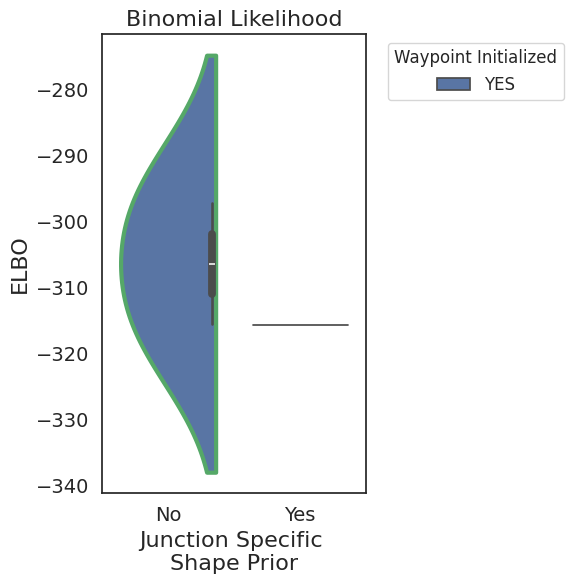

In [15]:
# Create the violin plot
plt.figure(figsize=(6, 6))

AT_SUB_bin["ELBO"] = -1 * AT_SUB_bin["best_elbo_trans"]

ax = sns.violinplot(
    data=AT_SUB_bin, 
    x="junc_prior", 
    y="ELBO", 
    hue="Waypoint Initialized",  # Use the 'Waypoint Initialized' for hue
    gap=.1,
    split=True  # Split by the new combined variable
)

# Set the x-axis and y-axis labels
plt.xlabel("Junction Specific \nShape Prior", fontsize=16)
plt.ylabel("ELBO", fontsize=16)
plt.title("Binomial Likelihood", fontsize=16)

# Customize tick label size
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Outline the violins using the custom palette colors
for i, violin in enumerate(ax.collections):  # Select every second collection (the violin bodies)
    violin.set_edgecolor(custom_palette['Binomial'])  
    violin.set_linewidth(3)

# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Waypoint Initialized", fontsize=12)
# Show the plot
plt.tight_layout()

plt.savefig('Binomial_Lik_ELBO.pdf', bbox_inches='tight', format='pdf')
plt.show()

/scratch/ipykernel_34489/2005656392.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  AT_SUB_bb["ELBO"] = -1 * AT_SUB_bb["best_elbo_trans"]


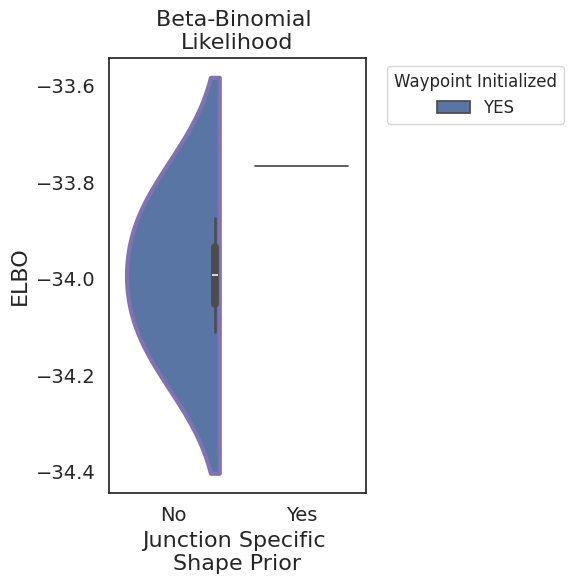

In [16]:
# Create the violin plot
AT_SUB_bb["ELBO"] = -1 * AT_SUB_bb["best_elbo_trans"]

plt.figure(figsize=(6, 6))
ax = sns.violinplot(
    data=AT_SUB_bb, 
    x="junc_prior", 
    y="ELBO", 
    hue="Waypoint Initialized",  # Use the 'Waypoint Initialized' for hue
    gap=.1,
    split=True  # Split by the new combined variable
)

# Set the x-axis and y-axis labels
plt.xlabel("Junction Specific \nShape Prior", fontsize=16)
plt.ylabel("ELBO", fontsize=16)
plt.title("Beta-Binomial \nLikelihood", fontsize=16)

# Customize tick label size
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Outline the violins using the custom palette colors
for i, violin in enumerate(ax.collections):  # Select every second collection (the violin bodies)
    violin.set_edgecolor(custom_palette['Beta-Binomial'])  
    violin.set_linewidth(3)

# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Waypoint Initialized", fontsize=12)

# Show the plot
plt.tight_layout()
plt.savefig('BB_Lik_ELBO.pdf', bbox_inches='tight', format='pdf')
plt.show()

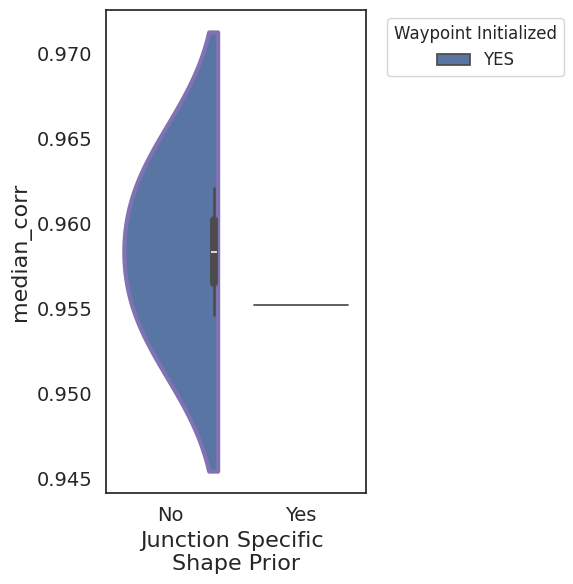

In [17]:
# Create the violin plot
plt.figure(figsize=(6, 6))
ax = sns.violinplot(
    data=AT_SUB_bb, 
    x="junc_prior", 
    y="median_corr", 
    hue="Waypoint Initialized",  # Use the 'Waypoint Initialized' for hue
    gap=.1,
    split=True  # Split by the new combined variable
)

# Set the x-axis and y-axis labels
plt.xlabel("Junction Specific \nShape Prior", fontsize=16)
plt.ylabel("median_corr", fontsize=16)

# Customize tick label size
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Outline the violins using the custom palette colors
for i, violin in enumerate(ax.collections):  # Select every second collection (the violin bodies)
    violin.set_edgecolor(custom_palette['Beta-Binomial'])  
    violin.set_linewidth(3)

# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Waypoint Initialized", fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

In [19]:
AT_SUB_bb.sort_values(by="new_K")

,K,new_K,use_global_prior,learning_rate,avg_corr,median_corr,min_corr,silhouette_avg,dbi,cell_type_column,...,ELBO_log10,Likelihood,junc_prior,combined_prior_input,unique_model_att,K_diff,Waypoint Initialized,best_elbo_trans,K_ord,ELBO
4,30,30,False,0.1,0.962266,0.962076,0.962001,-0.163032,9.860426,cell_type_grouped,...,7.529871,Beta-Binomial,No,noJ_prior-Beta-Binomial,noJ_prior-Beta-Binomial-YES-30,0,YES,33.874358,30,-33.874358
0,30,30,True,0.1,0.955326,0.955187,0.954999,-0.170576,10.015450,cell_type_grouped,...,7.528482,Beta-Binomial,Yes,J_prior-Beta-Binomial,J_prior-Beta-Binomial-YES-30,0,YES,33.766199,30,-33.766199
5,50,50,False,0.1,0.955815,0.954618,0.951462,-0.177861,9.686950,cell_type_grouped,...,7.532897,Beta-Binomial,No,noJ_prior-Beta-Binomial,noJ_prior-Beta-Binomial-YES-50,0,YES,34.111208,50,-34.111208


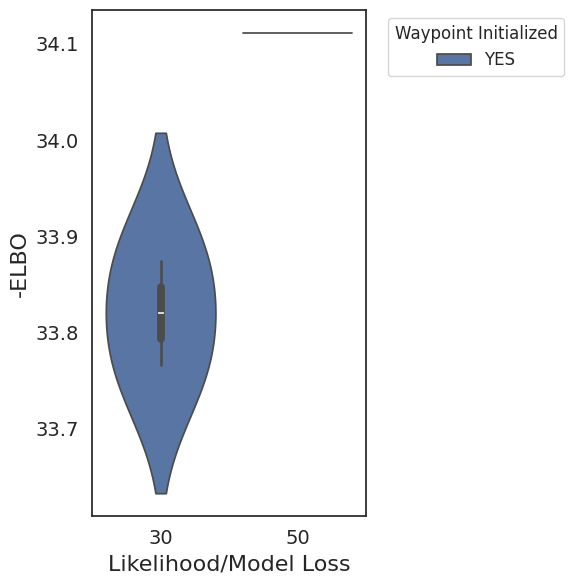

In [20]:
# Create the violin plot
plt.figure(figsize=(6, 6))
ax = sns.violinplot(
    data=AT_SUB_bb, 
    x="K", 
    y="best_elbo_trans", 
    hue="Waypoint Initialized",  # Use the 'Waypoint Initialized' for hue
    )

# Set the x-axis and y-axis labels
plt.xlabel("Likelihood/Model Loss", fontsize=16)
plt.ylabel("-ELBO", fontsize=16)

# Customize tick label size
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Waypoint Initialized", fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

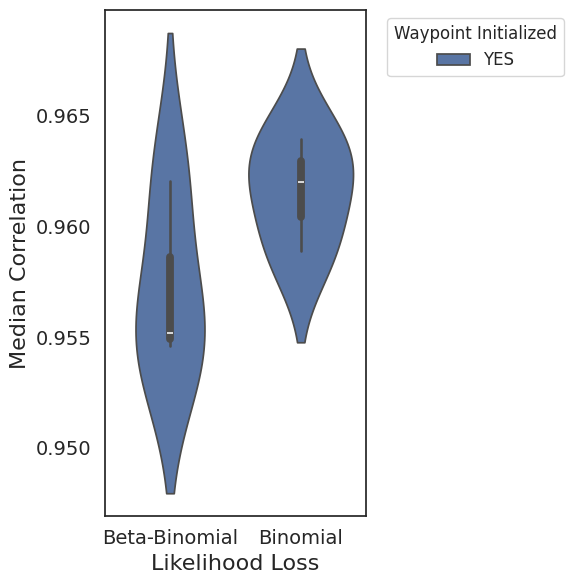

In [21]:
# Create the violin plot
plt.figure(figsize=(6, 6))
ax = sns.violinplot(
    data=all_TS_files_df, 
    x="Likelihood", 
    y="median_corr", 
    hue="Waypoint Initialized",  # Use the 'Waypoint Initialized' for hue
    )

# Set the x-axis and y-axis labels
plt.xlabel("Likelihood Loss", fontsize=16)
plt.ylabel("Median Correlation", fontsize=16)

# Customize tick label size
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Waypoint Initialized", fontsize=12)

# Show the plot
plt.tight_layout()
plt.savefig('MedianCorrelation_Waypoints_Likelihoods.pdf', bbox_inches='tight', format='pdf')
plt.show()

In [29]:
all_TS_files_df

,K,new_K,use_global_prior,learning_rate,avg_corr,median_corr,min_corr,silhouette_avg,dbi,cell_type_column,...,overall_cell_total_entropy,Source,ELBO_log10,Likelihood,junc_prior,combined_prior_input,unique_model_att,K_diff,Waypoint Initialized,best_elbo_trans
0,50,50,True,0.1,0.960496,0.959979,0.959377,-0.123036,13.663641,cell_type_grouped,...,43151.355358,All_Tabula_Sapien,8.472791,Binomial,J_prior,J_prior-Binomial,J_prior-Binomial-YES-50,0,YES,297.023927
1,30,30,True,0.1,0.955326,0.955187,0.954999,-0.170576,10.015450,cell_type_grouped,...,59176.258073,All_Tabula_Sapien,7.528482,Beta-Binomial,J_prior,J_prior-Beta-Binomial,J_prior-Beta-Binomial-YES-30,0,YES,33.766199
2,50,50,True,0.1,0.931433,0.931565,0.930246,-0.188205,9.561916,cell_type_grouped,...,71567.396911,All_Tabula_Sapien,7.531116,Beta-Binomial,J_prior,J_prior-Beta-Binomial,J_prior-Beta-Binomial-YES-50,0,YES,33.971601
3,50,50,False,0.1,0.960462,0.958874,0.958449,-0.122607,13.642172,cell_type_grouped,...,43197.798711,All_Tabula_Sapien,8.473106,Binomial,noJ_prior,noJ_prior-Binomial,noJ_prior-Binomial-YES-50,0,YES,297.239210
4,30,30,True,0.1,0.962531,0.962003,0.960933,-0.121699,13.200528,cell_type_grouped,...,40504.507939,All_Tabula_Sapien,8.499154,Binomial,J_prior,J_prior-Binomial,J_prior-Binomial-YES-30,0,YES,315.612088
5,30,30,False,0.1,0.963874,0.963936,0.962691,-0.118912,13.203882,cell_type_grouped,...,40559.988687,All_Tabula_Sapien,8.499017,Binomial,noJ_prior,noJ_prior-Binomial,noJ_prior-Binomial-YES-30,0,YES,315.512493
6,30,30,False,0.1,0.962266,0.962076,0.962001,-0.163032,9.860426,cell_type_grouped,...,56570.118362,All_Tabula_Sapien,7.529871,Beta-Binomial,noJ_prior,noJ_prior-Beta-Binomial,noJ_prior-Beta-Binomial-YES-30,0,YES,33.874358
7,50,50,False,0.1,0.955815,0.954618,0.951462,-0.177861,9.686950,cell_type_grouped,...,64833.848804,All_Tabula_Sapien,7.532897,Beta-Binomial,noJ_prior,noJ_prior-Beta-Binomial,noJ_prior-Beta-Binomial-YES-50,0,YES,34.111208


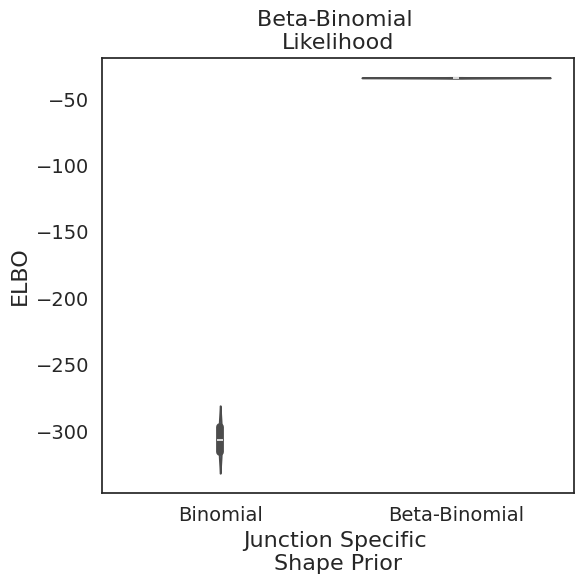

In [32]:
all_TS_files_df["ELBO"] = -1 * all_TS_files_df["best_elbo_trans"]

plt.figure(figsize=(6, 6))
ax = sns.violinplot(
    data=all_TS_files_df, 
    x="Likelihood", 
    y="ELBO")

# Set the x-axis and y-axis labels
plt.xlabel("Junction Specific \nShape Prior", fontsize=16)
plt.ylabel("ELBO", fontsize=16)
plt.title("Beta-Binomial \nLikelihood", fontsize=16)

# Customize tick label size
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Show the plot
plt.tight_layout()
plt.savefig('Lik_vs_ELBO.pdf', bbox_inches='tight', format='pdf')
plt.show()